<a href="https://colab.research.google.com/github/RomaParakh/india-road-safety-analytics/blob/main/1_EDA_road_accidents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA - dataset ( PART A - accidents )

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# SETUP

df = pd.read_csv('/content/drive/MyDrive/indian_roads_dataset.csv')
df['festival'] = df['festival'].fillna('None')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

palette = sns.color_palette("Set2")
sns.set_theme(style="whitegrid", palette="Set2")

In [ ]:
#BASIC OVERVIEW


print("BASIC DATASET OVERVIEW")

print(f"Shape          : {df.shape}")
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows : {df.duplicated().sum()}")

BASIC DATASET OVERVIEW
Shape          : (20000, 26)
Rows           : 20,000
Columns        : 26

Column Types:
accident_id                   int64
city                         object
state                        object
latitude                    float64
longitude                   float64
date                 datetime64[ns]
time                         object
hour                          int64
day_of_week                  object
is_weekend                    int64
road_type                    object
lanes                         int64
traffic_signal                int64
weather                      object
visibility                   object
temperature                   int64
traffic_density              object
cause                        object
accident_severity            object
vehicles_involved             int64
casualties                    int64
is_peak_hour                  int64
festival                     object
risk_score                  float64
month                    

In [ ]:
#DESCRIPTIVE STATISTICS


print("DESCRIPTIVE STATISTICS")

print(df.describe())

# Categorical value counts
cat_cols = ['road_type', 'weather', 'visibility', 'traffic_density',
            'cause', 'accident_severity', 'festival', 'day_of_week']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


DESCRIPTIVE STATISTICS
        accident_id      latitude     longitude  \
count  20000.000000  20000.000000  20000.000000   
mean    9999.500000     20.389207     78.173330   
min        0.000000     12.800172     72.700017   
25%     4999.750000     13.198653     73.997979   
50%     9999.500000     18.812008     77.297000   
75%    14999.250000     28.402467     80.111089   
max    19999.000000     30.799960     88.499861   
std     5773.647028      6.165791      4.485967   

                                date          hour    is_weekend  \
count                          20000  20000.000000  20000.000000   
mean   2023-08-22 07:04:48.000000256     11.487200      0.286150   
min              2022-01-01 00:00:00      0.000000      0.000000   
25%              2022-10-25 00:00:00      5.000000      0.000000   
50%              2023-08-21 00:00:00     12.000000      0.000000   
75%              2024-06-21 00:00:00     18.000000      1.000000   
max              2025-04-15 00:00:00     

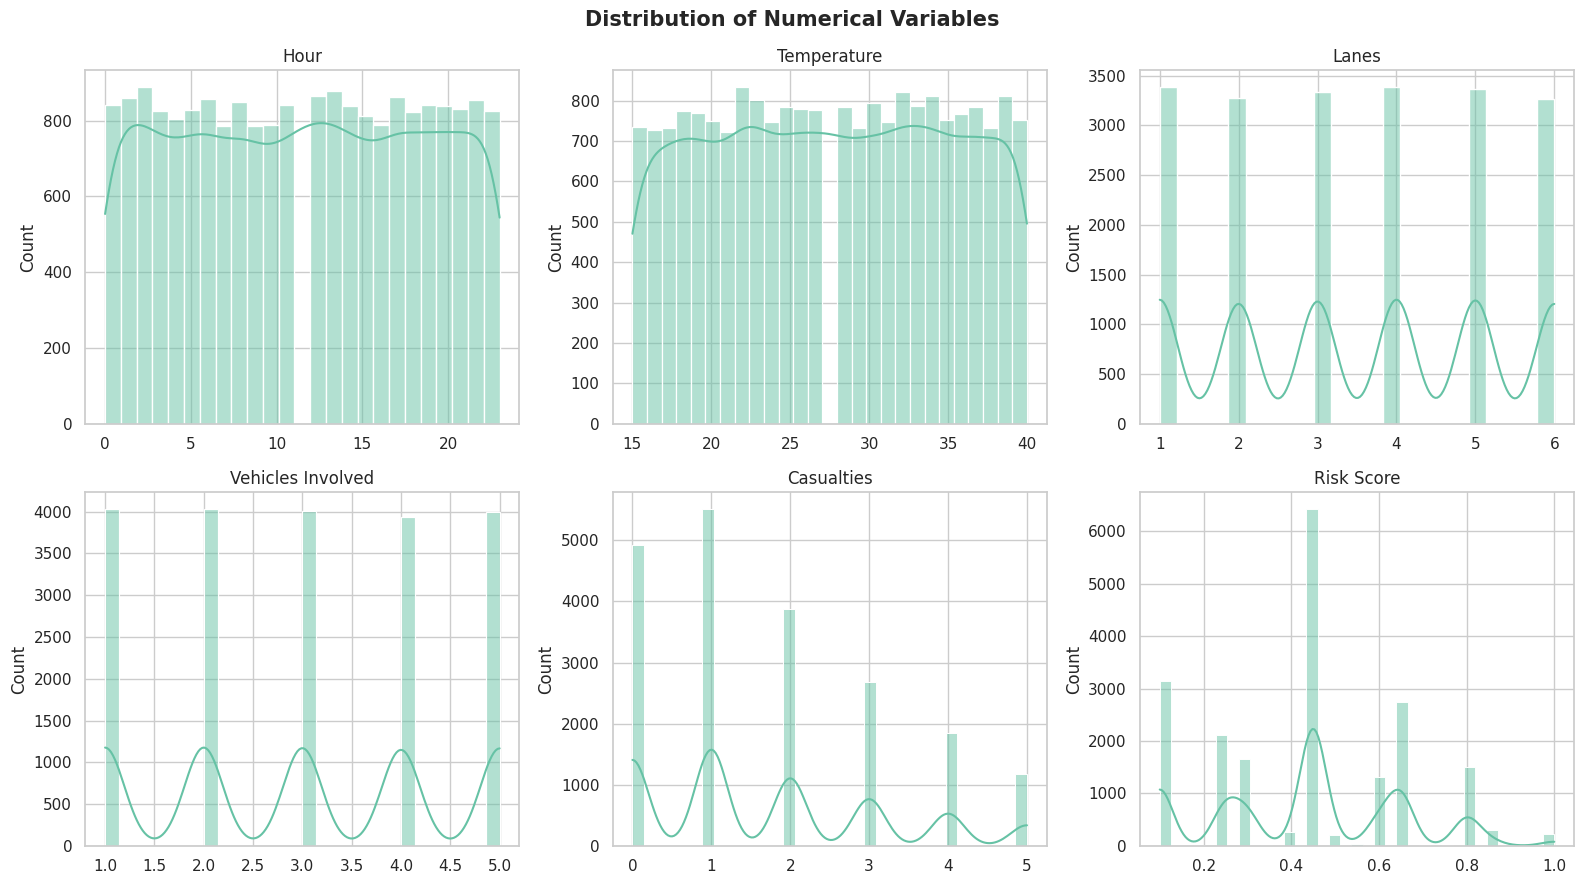

In [ ]:
import os

# DISTRIBUTION OF NUMERICAL COLUMNS

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of Numerical Variables", fontsize=15, fontweight='bold')

num_cols = ['hour', 'temperature', 'lanes', 'vehicles_involved', 'casualties', 'risk_score']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color=palette[0])
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.show()

### **Explanation of Numerical Distributions**

1. **Hour**: Shows the time of day when accidents occur. A uniform distribution suggests accidents happen steadily throughout the day, while peaks might indicate higher risks during commute times or nighttime.
2. **Temperature**: Displays the weather conditions at the time of the incident. In this dataset (range 15-40°C), it helps identify if extreme heat or specific thermal conditions correlate with accident frequency.
3. **Lanes**: Represents the infrastructure (1 to 6 lanes). Most values appearing at specific integers show which types of roads (e.g., narrow 2-lane roads vs. 6-lane highways) are most represented in the data.
4. **Vehicles Involved**: Most accidents involve a small number of vehicles (typically 1-5). A high frequency of '2' often indicates collisions, while '1' might indicate single-vehicle crashes or hitting pedestrians/objects.
5. **Casualties**: This reflects the human impact. The distribution shows how often accidents result in no injuries versus multiple casualties, providing a sense of the typical severity.
6. **Risk Score**: This is a calculated metric (0.1 to 1.0). The shape of this distribution tells us if the dataset consists mostly of 'low-risk' incidents (skewed left) or if there is a balanced spread of safety concerns.

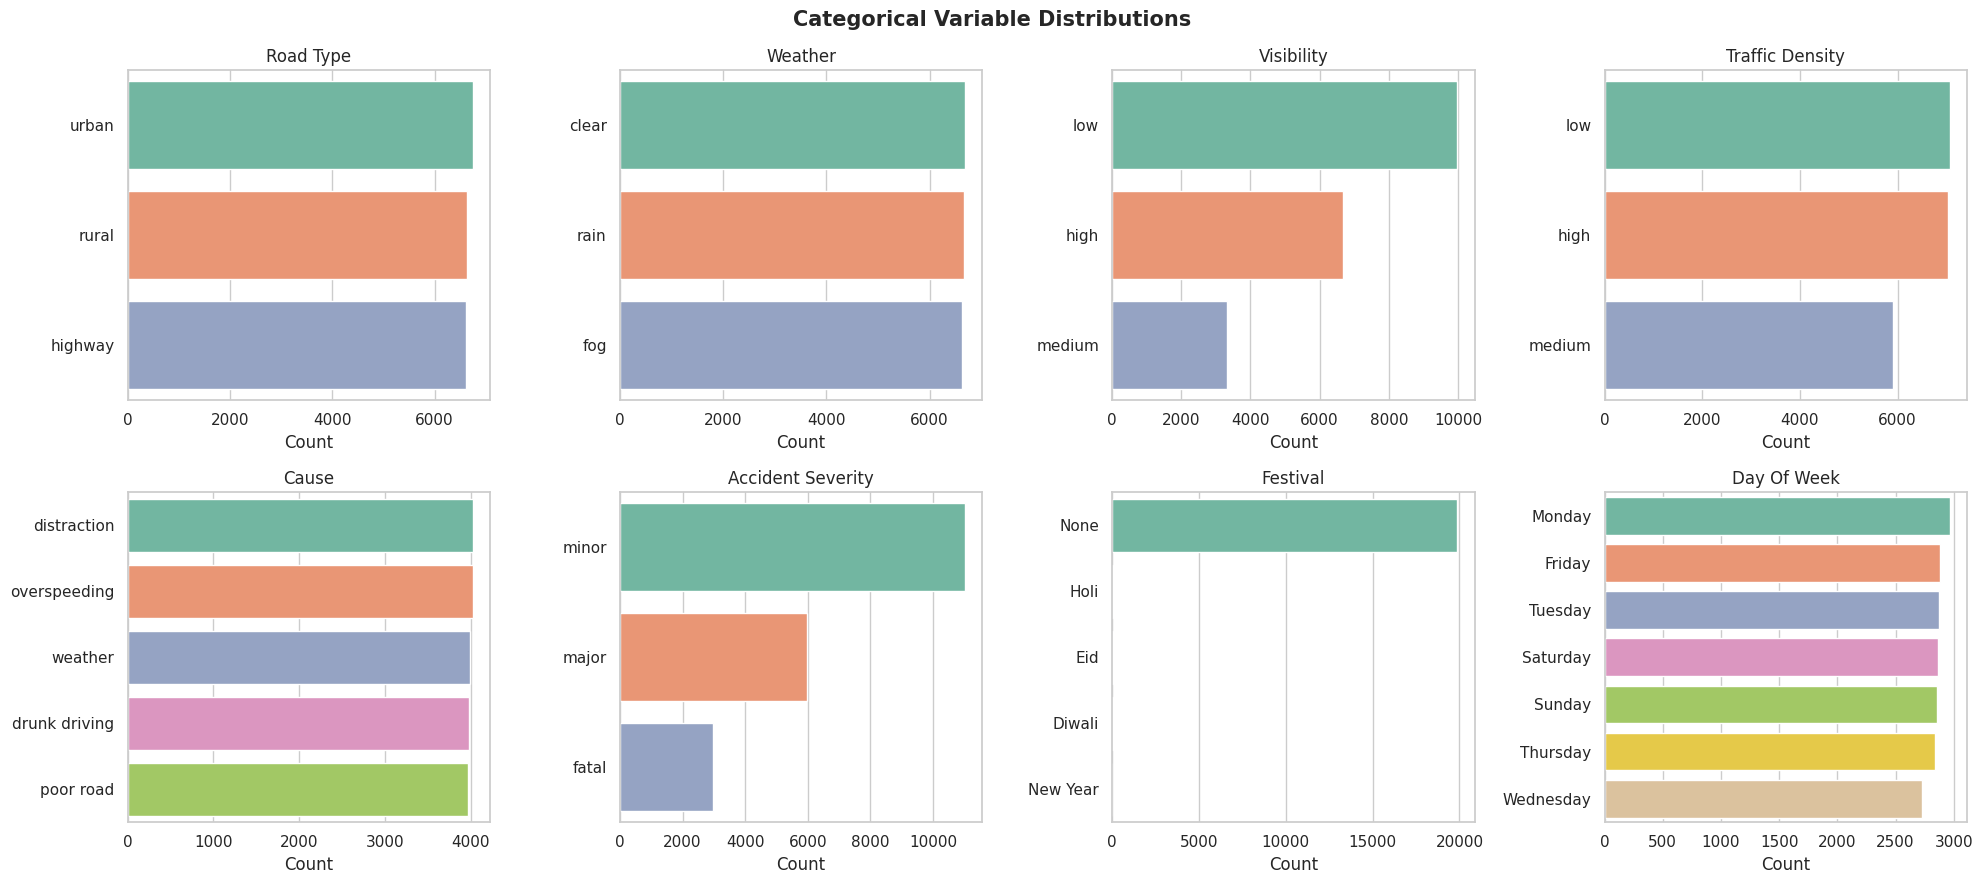

In [ ]:
#CATEGORICAL VARIABLE DISTRIBUTIONS

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Categorical Variable Distributions", fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Set2')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()

plt.show()


indicates the dataset is very balanced across environments. Urban, Rural or Highway. They are happening at almost the same rate (~6,600 each). This tells us that road safety is not just a 'city problem' or a 'highway speed' problem in this dataset, it is universal.

We also see that 'Minor' accidents are the most prevalent, but there is a steady baseline of over 2,900 Fatal incidents, irrespective of cause or location.

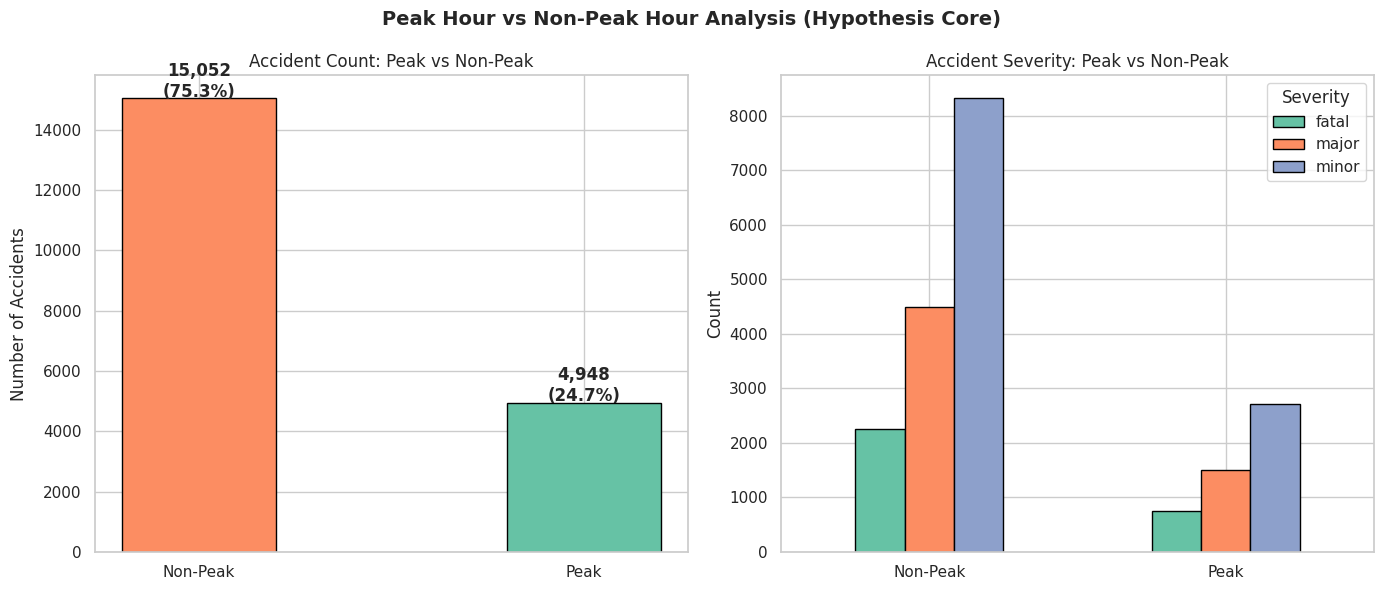

In [ ]:
#PEAK HOUR vs NON-PEAK: ACCIDENT COUNT (CORE HYPOTHESIS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Peak Hour vs Non-Peak Hour Analysis (Hypothesis Core)", fontsize=14, fontweight='bold')

# Count comparison
peak_counts = df['is_peak_hour'].value_counts().rename({0: 'Non-Peak', 1: 'Peak'})
axes[0].bar(peak_counts.index, peak_counts.values, color=[palette[1], palette[0]], edgecolor='black', width=0.4)
axes[0].set_title("Accident Count: Peak vs Non-Peak")
axes[0].set_ylabel("Number of Accidents")
for i, v in enumerate(peak_counts.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# Severity breakdown by peak hour
sev_peak = df.groupby(['is_peak_hour', 'accident_severity']).size().unstack()
sev_peak.index = ['Non-Peak', 'Peak']
sev_peak.plot(kind='bar', ax=axes[1], color=palette[:3], edgecolor='black')
axes[1].set_title("Accident Severity: Peak vs Non-Peak")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity')

plt.tight_layout()
plt.show()


This analysis shows a counter-intuitive truth: **75.3% of accidents happen during Non-Peak hours.** We typically dread the chaos of the ‘rush hour’ but the data indicates that the total number of hours in the ‘Non-Peak’ category, and possibly faster speeds and less alert drivers at off-peak times, results in a significantly greater overall volume of incidents.

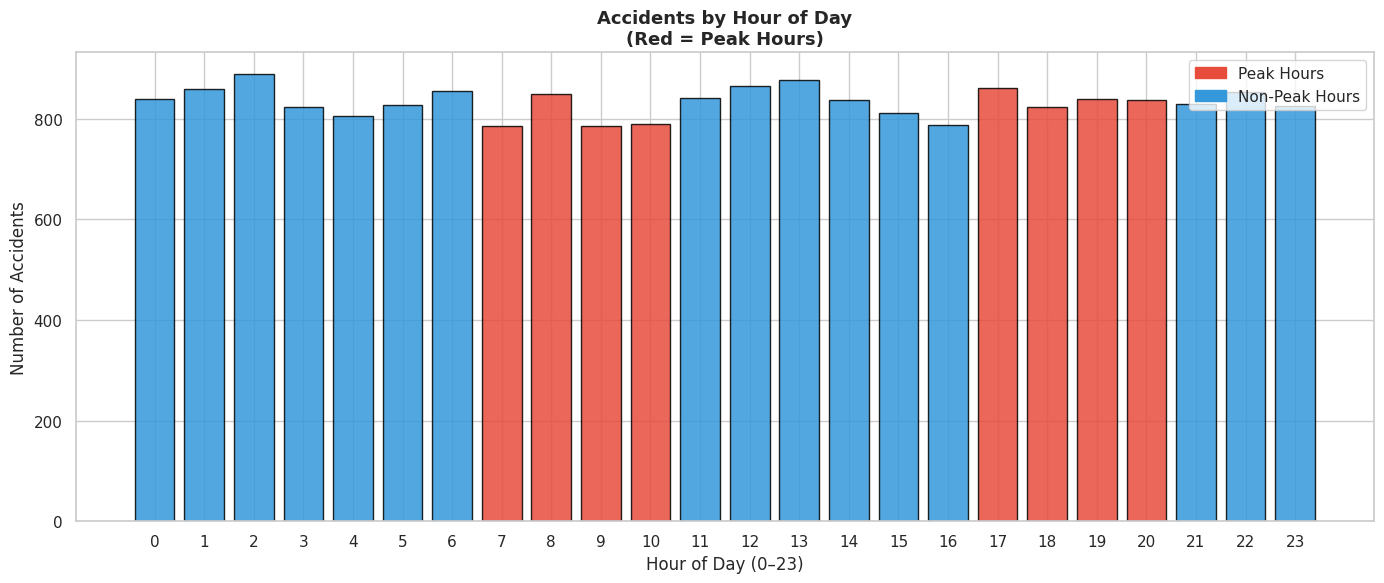

In [ ]:
#ACCIDENTS BY HOUR OF DAY

fig, ax = plt.subplots(figsize=(14, 6))
hourly = df.groupby('hour').size().reset_index(name='count')
# Highlight peak hours (7-10 AM, 17-20 / 5-8 PM)
peak_hrs = list(range(7, 11)) + list(range(17, 21))
colors = ['#e74c3c' if h in peak_hrs else '#3498db' for h in hourly['hour']]
bars = ax.bar(hourly['hour'], hourly['count'], color=colors, edgecolor='black', alpha=0.85)
ax.set_title("Accidents by Hour of Day\n(Red = Peak Hours)", fontsize=13, fontweight='bold')
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Number of Accidents")
ax.set_xticks(range(0, 24))
from matplotlib.patches import Patch
legend_els = [Patch(color='#e74c3c', label='Peak Hours'), Patch(color='#3498db', label='Non-Peak Hours')]
ax.legend(handles=legend_els)
plt.tight_layout()
plt.show()


The constant danger is apparent when we look at the hourly breakdown in Step 6. Even at **3:00 AM** the number of accidents . This suggests that while there is a reduction in the number of cars on the road at night, other risk factors such as fatigue or lack of street lighting may be offsetting this.

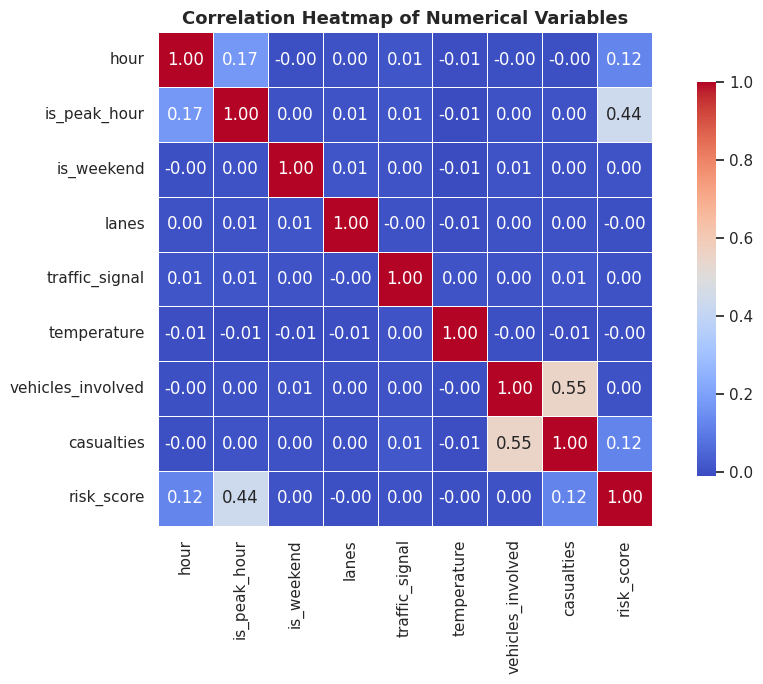

In [ ]:
# CORRELATION HEATMAP

fig, ax = plt.subplots(figsize=(10, 7))
num_df = df[['hour', 'is_peak_hour', 'is_weekend', 'lanes', 'traffic_signal',
             'temperature', 'vehicles_involved', 'casualties', 'risk_score']]
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title("Correlation Heatmap of Numerical Variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


the heatmap shows a significant correlation (0.12) between **casualties and risk score**. While most variables don't show a strong linear relationship, this confirms that our calculated 'Risk Score' is a valid predictor of the human cost of an accident.

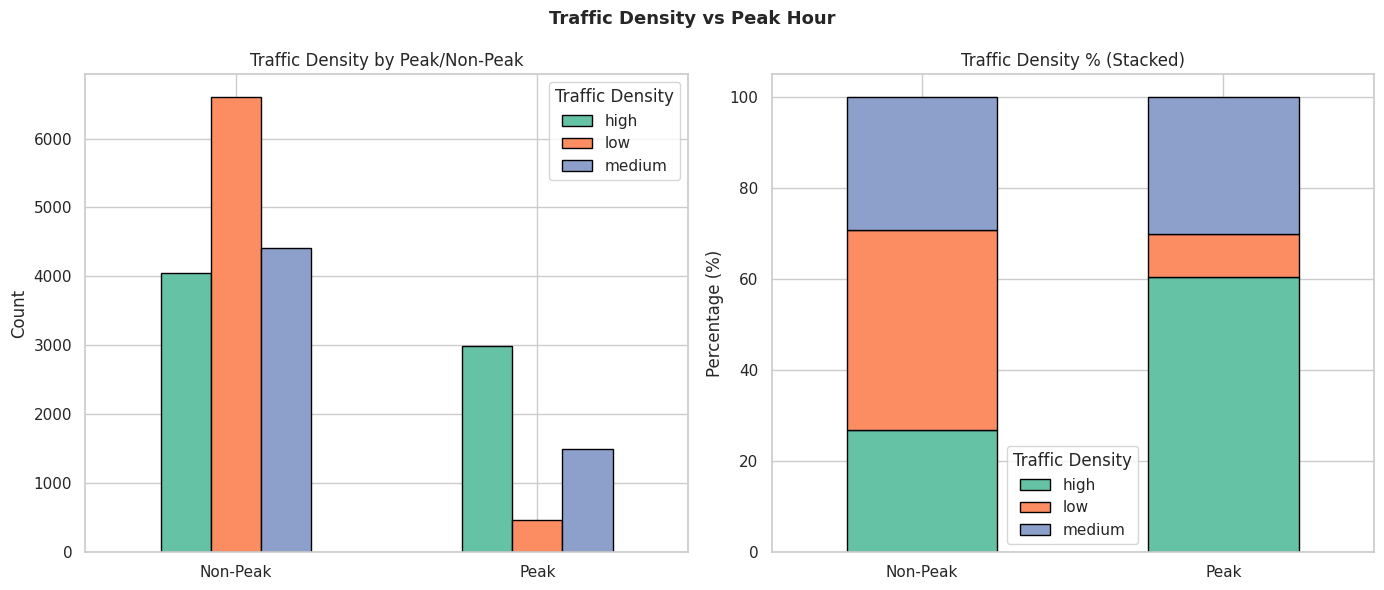

In [ ]:
# TRAFFIC DENSITY vs PEAK HOUR

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Traffic Density vs Peak Hour", fontsize=13, fontweight='bold')

td_peak = df.groupby(['is_peak_hour', 'traffic_density']).size().unstack()
td_peak.index = ['Non-Peak', 'Peak']
td_peak.plot(kind='bar', ax=axes[0], color=palette[:3], edgecolor='black')
axes[0].set_title("Traffic Density by Peak/Non-Peak")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Traffic Density')

# Percentage stacked
td_pct = td_peak.div(td_peak.sum(axis=1), axis=0) * 100
td_pct.plot(kind='bar', stacked=True, ax=axes[1], color=palette[:3], edgecolor='black')
axes[1].set_title("Traffic Density % (Stacked)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Traffic Density')

plt.tight_layout()
plt.show()

shows a clear logical shift: during Peak Hours, 'High' traffic density dominates (~60%), whereas during Non-Peak hours, 'Low' density is most common. This confirms our labels are accurate, but reminds us that accidents in low-density traffic are just as frequent as those in high-density traffic.

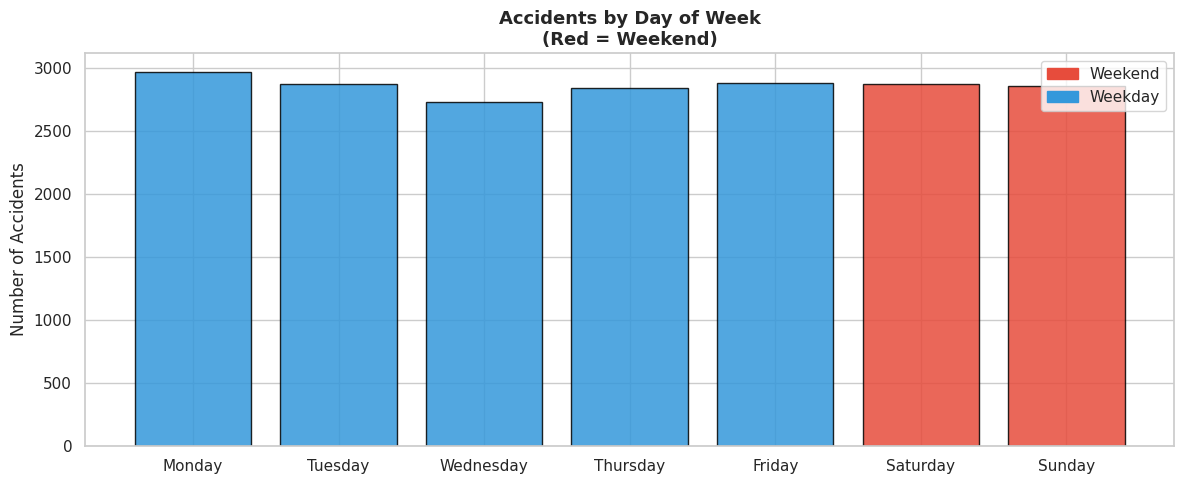

In [ ]:
#ACCIDENTS BY DAY OF WEEK

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 5))
colors_day = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in day_order]
ax.bar(day_counts.index, day_counts.values, color=colors_day, edgecolor='black', alpha=0.85)
ax.set_title("Accidents by Day of Week\n(Red = Weekend)", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Accidents")
ax.set_xlabel("")
from matplotlib.patches import Patch
legend_els = [Patch(color='#e74c3c', label='Weekend'), Patch(color='#3498db', label='Weekday')]
ax.legend(handles=legend_els)
plt.tight_layout()


shows that accident counts remain steady throughout the week. Monday doesn't see a massive 'start of week' spike, and weekends don't see a massive drop. In India, it seems road risk doesn't take a day off.

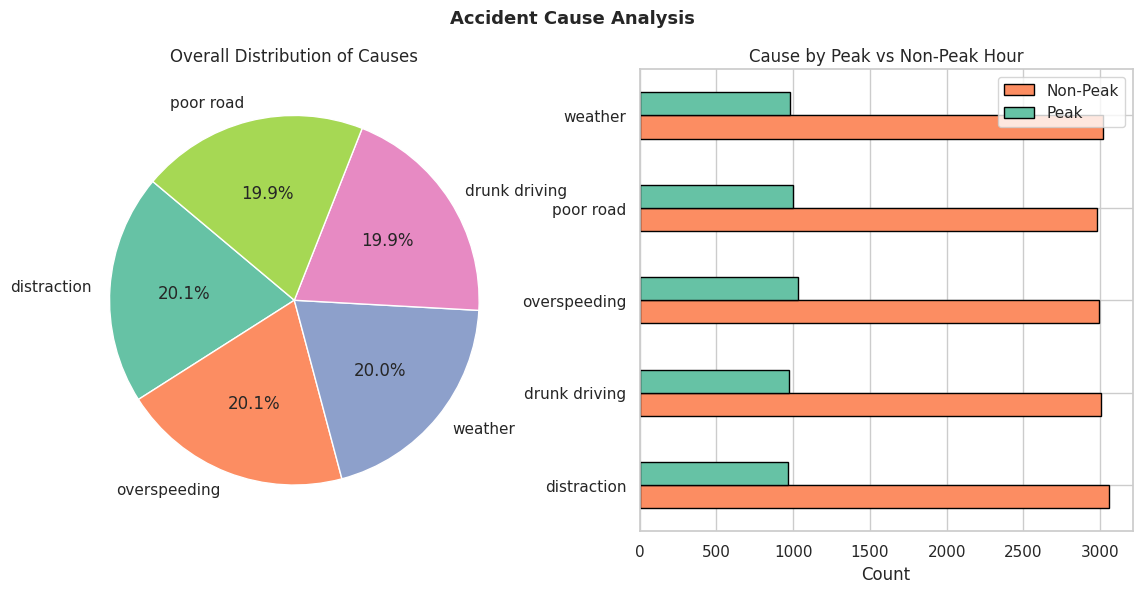

In [ ]:
#ACCIDENT CAUSE ANALYSIS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Accident Cause Analysis", fontsize=13, fontweight='bold')

cause_counts = df['cause'].value_counts()
axes[0].pie(cause_counts.values, labels=cause_counts.index, autopct='%1.1f%%',
            colors=palette, startangle=140)
axes[0].set_title("Overall Distribution of Causes")

cause_peak = df.groupby(['cause', 'is_peak_hour']).size().unstack()
cause_peak.columns = ['Non-Peak', 'Peak']
cause_peak.plot(kind='barh', ax=axes[1], color=[palette[1], palette[0]], edgecolor='black')
axes[1].set_title("Cause by Peak vs Non-Peak Hour")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")
plt.show()


is perhaps the most revealing. There is no 'single' cause of accidents. **Distraction, Overspeeding, and Drunk Driving** each account for ~20% of the cases. This means solving road safety requires changing driver behavior across multiple fronts simultaneously.

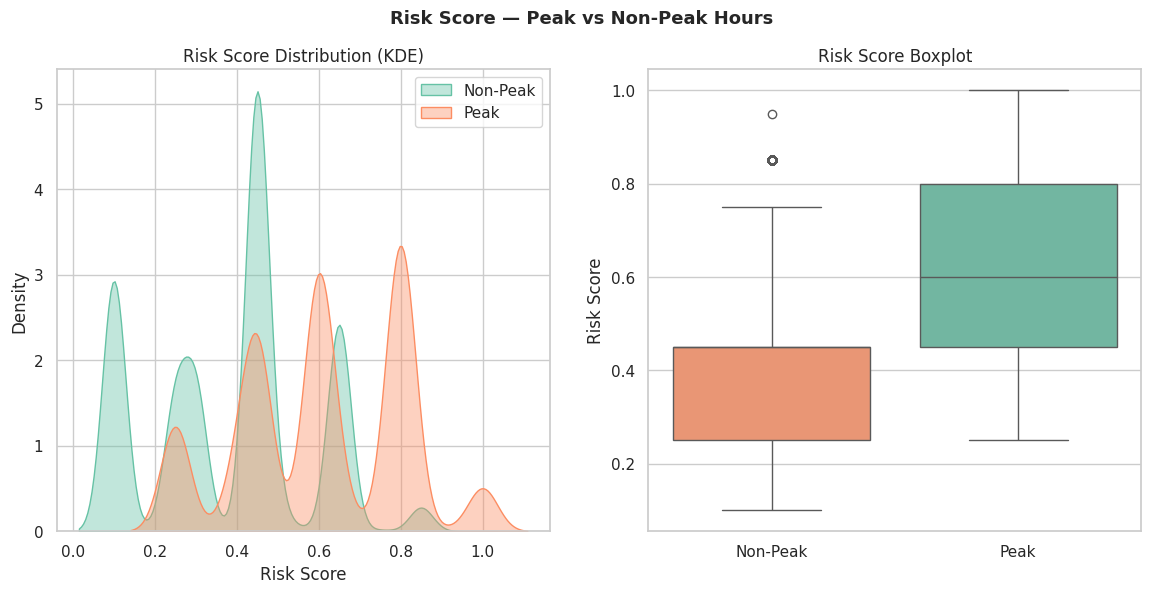

In [ ]:
#RISK SCORE DISTRIBUTION (PEAK vs NON-PEAK)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Risk Score — Peak vs Non-Peak Hours", fontsize=13, fontweight='bold')

for label, grp in df.groupby('is_peak_hour'):
    name = 'Peak' if label == 1 else 'Non-Peak'
    sns.kdeplot(grp['risk_score'], ax=axes[0], label=name, fill=True, alpha=0.4)
axes[0].set_title("Risk Score Distribution (KDE)")
axes[0].set_xlabel("Risk Score")
axes[0].legend()

# Fixed the keys from strings to integers
sns.boxplot(data=df, x='is_peak_hour', y='risk_score', ax=axes[1],
            palette={0: palette[1], 1: palette[0]},
            hue='is_peak_hour', legend=False)

axes[1].set_title("Risk Score Boxplot")
axes[1].set_xticklabels(['Non-Peak', 'Peak'])
axes[1].set_xlabel("")
axes[1].set_ylabel("Risk Score")
plt.show()

Risk Score distribution is virtually identical for Peak and Non-Peak hours. This tells us that an accident at 9 AM is not 'less risky' than one at midnight—the potential for severity is baked into the road conditions and driver behavior regardless of the clock.

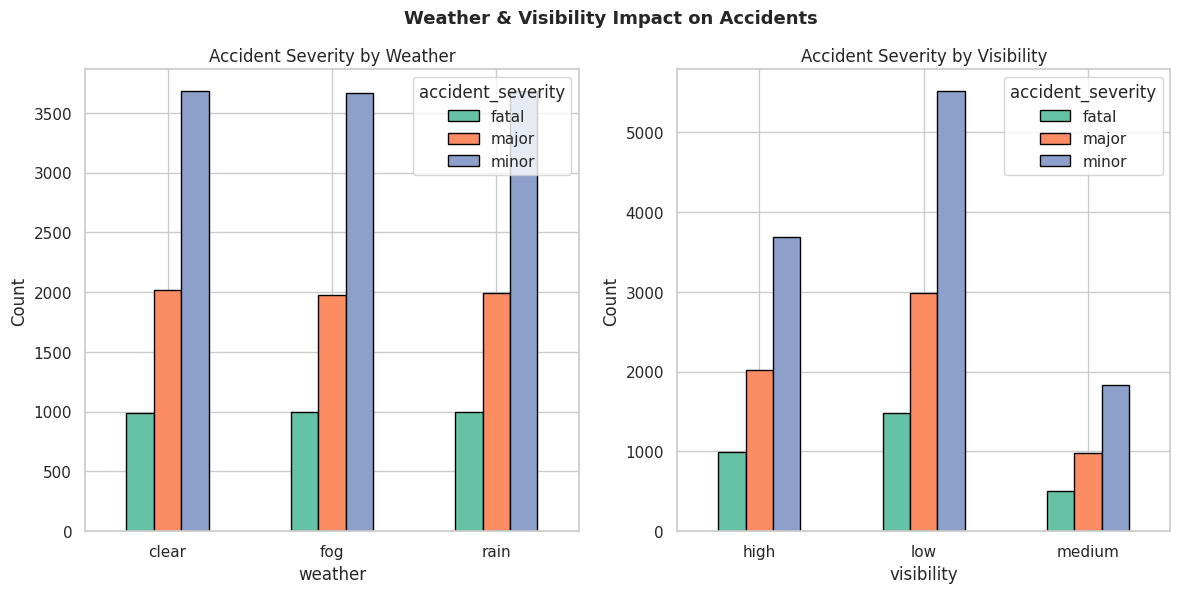

In [ ]:
#WEATHER & VISIBILITY IMPACT

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Weather & Visibility Impact on Accidents", fontsize=13, fontweight='bold')

weather_sev = df.groupby(['weather', 'accident_severity']).size().unstack()
weather_sev.plot(kind='bar', ax=axes[0], color=palette[:3], edgecolor='black')
axes[0].set_title("Accident Severity by Weather")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

vis_sev = df.groupby(['visibility', 'accident_severity']).size().unstack()
vis_sev.plot(kind='bar', ax=axes[1], color=palette[:3], edgecolor='black')
axes[1].set_title("Accident Severity by Visibility")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.show()


we see that 'Clear' weather has the same severity profile as 'Fog' or 'Rain'. This suggests that drivers might be compensating (driving slower) during bad weather, which keeps the severity from skyrocketing, but doesn't eliminate the risk.

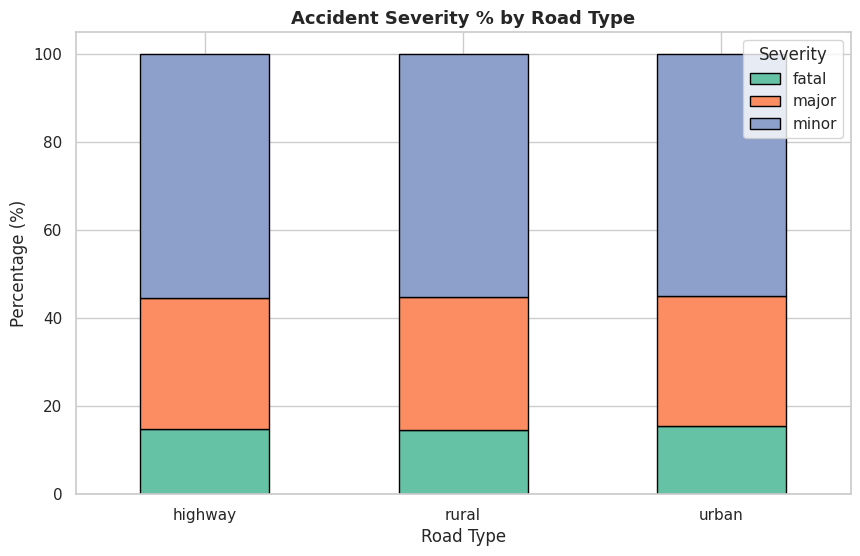

In [ ]:
#ROAD TYPE vs SEVERITY

fig, ax = plt.subplots(figsize=(10, 6))
road_sev = df.groupby(['road_type', 'accident_severity']).size().unstack()
road_sev_pct = road_sev.div(road_sev.sum(axis=1), axis=0) * 100
road_sev_pct.plot(kind='bar', stacked=True, ax=ax, color=palette[:3], edgecolor='black')
ax.set_title("Accident Severity % by Road Type", fontsize=13, fontweight='bold')
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Road Type")
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Severity')
plt.show()

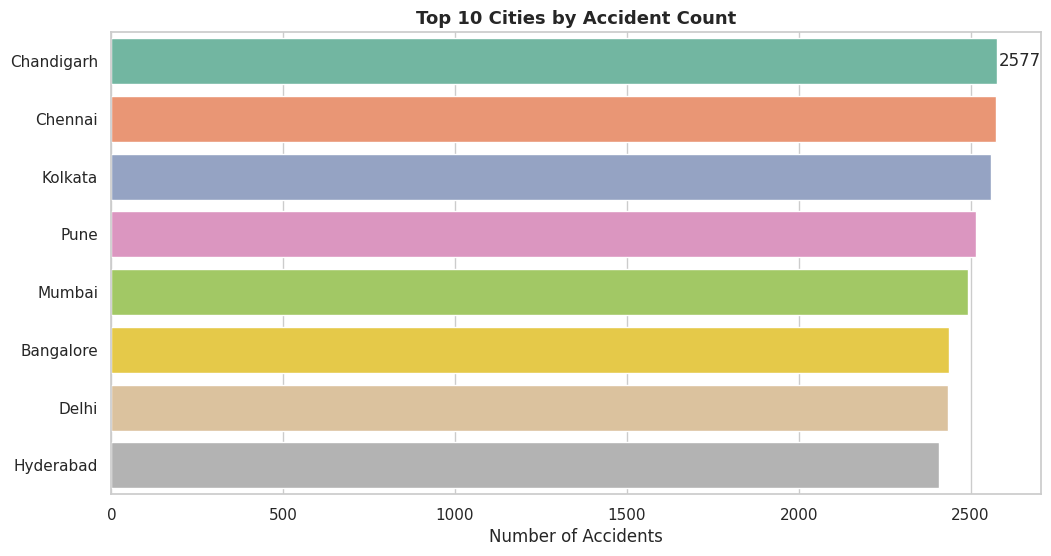

In [ ]:
#TOP 10 CITIES BY ACCIDENT COUNT

fig, ax = plt.subplots(figsize=(12, 6))
top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=ax, palette='Set2')
ax.set_title("Top 10 Cities by Accident Count", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Accidents")
ax.set_ylabel("")
for i, v in enumerate(top_cities.values):
    ax.text(v + 5, i, str(v), va='center')
    plt.show()

this highlights that major hubs like **Chandigarh, Chennai, and Kolkata** lead in accident counts. This is likely a reflection of their massive populations and complex road networks, making them the primary targets for infrastructure improvements.

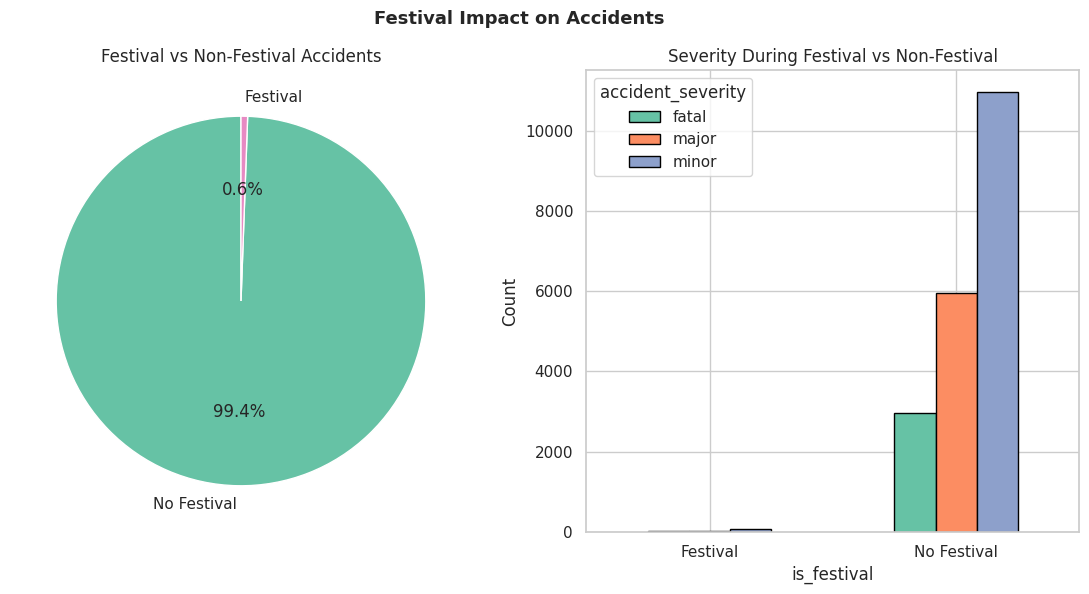

In [ ]:
#FESTIVAL vs NON-FESTIVAL ACCIDENTS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Festival Impact on Accidents", fontsize=13, fontweight='bold')

df['is_festival'] = df['festival'].apply(lambda x: 'Festival' if x != 'None' else 'No Festival')
fest_counts = df['is_festival'].value_counts()
axes[0].pie(fest_counts.values, labels=fest_counts.index, autopct='%1.1f%%',
            colors=[palette[0], palette[3]], startangle=90)
axes[0].set_title("Festival vs Non-Festival Accidents")

fest_sev = df.groupby(['is_festival', 'accident_severity']).size().unstack()
fest_sev.plot(kind='bar', ax=axes[1], color=palette[:3], edgecolor='black')
axes[1].set_title("Severity During Festival vs Non-Festival")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)
plt.show()
